In [1]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
results_df = pd.read_csv('output/integration_analysis/summary_complete.csv')

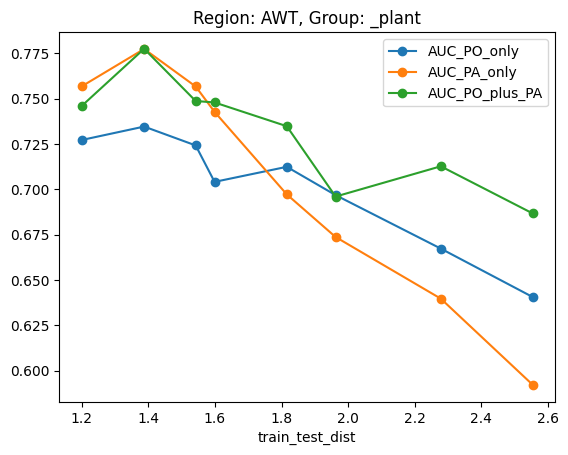

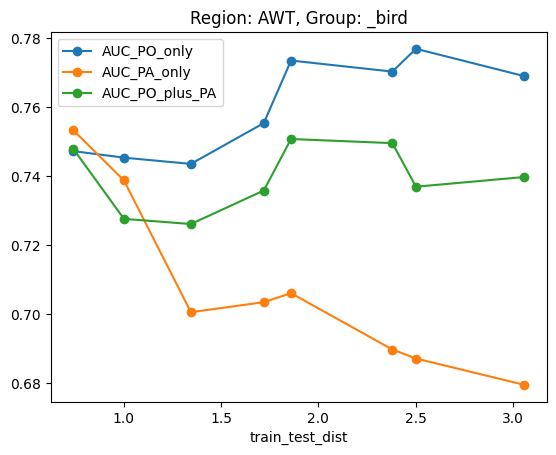

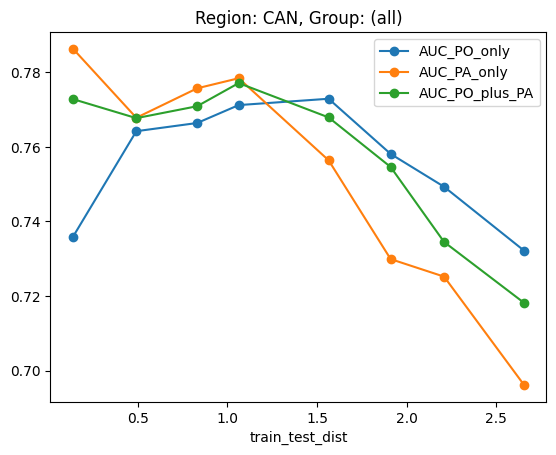

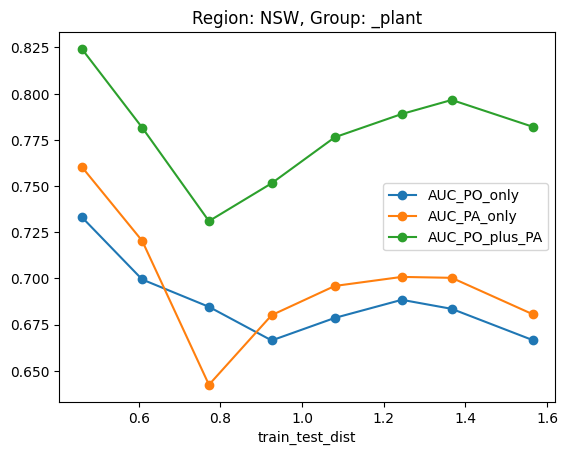

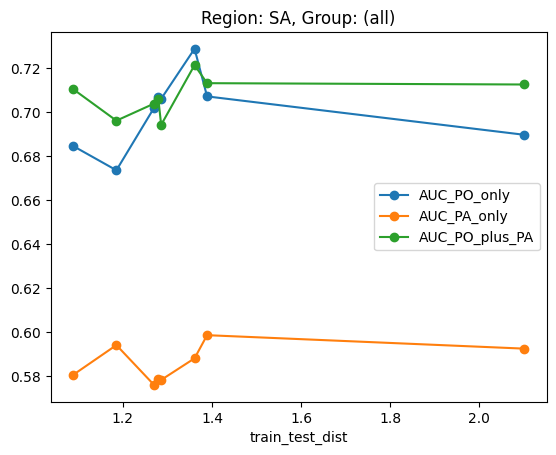

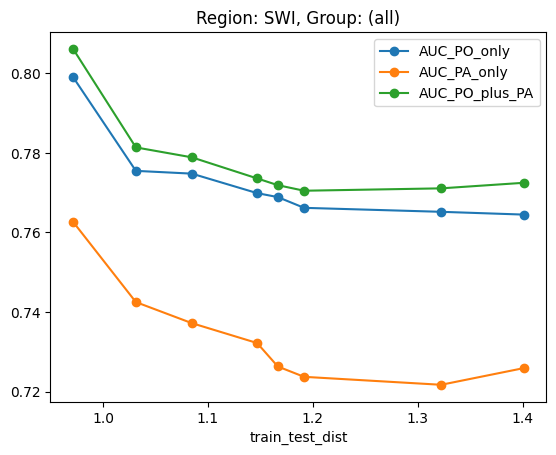

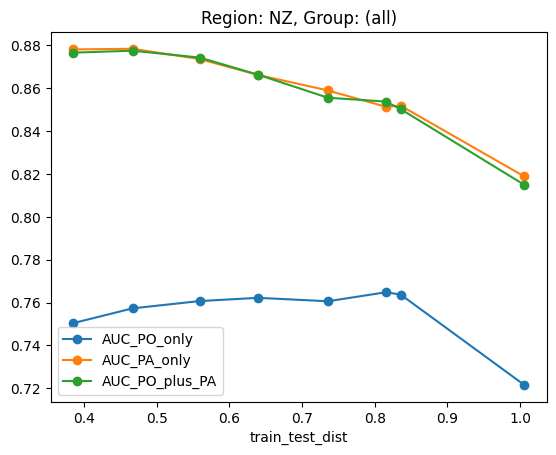

In [4]:
regions = results_df['region'].unique()
for region in regions:
    df_region = results_df[results_df['region'] == region]
    groups = df_region['group'].unique()
    for group in groups:
        df_region_group = df_region[df_region['group'] == group]
        # sort by train_test_dist
        df_region_group = df_region_group.sort_values(by='train_test_dist', ascending=False)
        # plot
        df_region_group.plot(x='train_test_dist', 
                             y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"
                                # , "AUC_PO_plus_PA_smooth", "AUC_PO_plus_PA_ens"
                                ], 
                             marker='o', title=f'Region: {region}, Group: {group}')


In [100]:
results_df.groupby(['region', 'group']).mean()[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA', 'AUC_PO_plus_PA_smooth',  "AUC_PO_plus_PA_ens"]].mean()

AUC_PO_only                   NaN
AUC_PA_only                   NaN
AUC_PO_plus_PA           0.815700
AUC_PO_plus_PA_smooth    0.775262
AUC_PO_plus_PA_ens            NaN
dtype: float64

<Axes: xlabel='train_test_dist'>

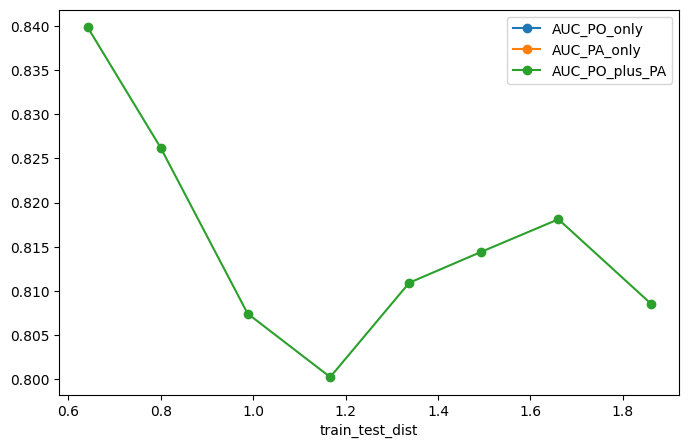

In [101]:
results_df.sort_values(by = 'train_test_dist').plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    marker="o",
    figsize=(8,5)
)


<Axes: xlabel='train_test_dist'>

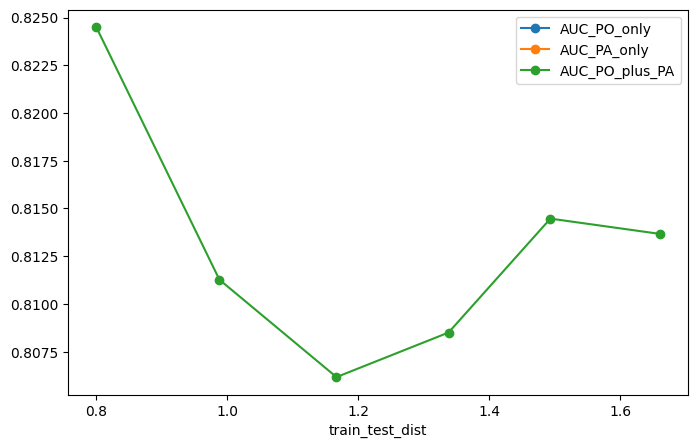

In [102]:
df = results_df.sort_values('train_test_dist').copy()

# Apply rolling mean smoothing (window=3 is typical; adjust as needed)
df[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA']] = (
    df[['AUC_PO_only', 'AUC_PA_only', 'AUC_PO_plus_PA']]
      .rolling(window=3, center=True)
      .mean()
)

df.plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    marker="o",
    figsize=(8,5)
)


In [103]:
from statsmodels.nonparametric.smoothers_lowess import lowess

df = results_df.sort_values('train_test_dist').copy()

for col in ["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"]:
    smoothed = lowess(df[col], df['train_test_dist'], frac=0.3)
    df[col] = smoothed[:,1]

df.plot(
    x="train_test_dist",
    y=["AUC_PO_only", "AUC_PA_only", "AUC_PO_plus_PA"],
    kind="line",
    figsize=(8,5)
)


C:\Users\pablo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\pablo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: Length of values (0) does not match length of index (8)